# Actividad 18

## 1.- Obtenga el siguiente dataframe “Adult income dataset” de 
https://www.kaggle.com/datasets/wenruliu/adult-income-dataset

In [1]:

# ── 1. Librerías e importación del dataset Adult Income ───────────────────────
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub
import os
import warnings
warnings.filterwarnings('ignore')

# descargamos el dataset desde Kaggle
path = kagglehub.dataset_download("wenruliu/adult-income-dataset")
print("Archivos descargados en:", path)

# cargamos el CSV de forma dinámica (sin hardcodear el path del usuario)
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
DATA = pd.read_csv(os.path.join(path, csv_file))

print(f"\nDimensiones del dataset: {DATA.shape[0]} filas × {DATA.shape[1]} columnas")
print("\nColumnas:", list(DATA.columns))
DATA.head()


Using Colab cache for faster access to the 'adult-income-dataset' dataset.
Archivos descargados en: /kaggle/input/adult-income-dataset

Dimensiones del dataset: 48842 filas × 15 columnas

Columnas: ['age', 'workclass', 'fnlwgt', 'education', 'educational-num', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K



El dataset **Adult Income** contiene datos del censo de EE.UU. de 1994.  
El objetivo original es predecir si una persona gana más o menos de $50.000 al año.  
Cada fila representa una persona con sus características socioeconómicas.

Antes de aplicar privacidad diferencial, se realiza una exploración para entender la estructura de los datos y una recategorización de `age` que será necesaria para los pasos siguientes.


Tipos de datos:
age                 int64
workclass          object
fnlwgt              int64
education          object
educational-num     int64
marital-status     object
occupation         object
relationship       object
race               object
gender             object
capital-gain        int64
capital-loss        int64
hours-per-week      int64
native-country     object
income             object

Valores únicos por columna (variables categóricas):
  workclass           : 9 categorías → ['Private', 'Local-gov', '?', 'Self-emp-not-inc', 'Federal-gov']
  education           : 16 categorías → ['11th', 'HS-grad', 'Assoc-acdm', 'Some-college', '10th']
  marital-status      : 7 categorías → ['Never-married', 'Married-civ-spouse', 'Widowed', 'Divorced', 'Separated']
  occupation          : 15 categorías → ['Machine-op-inspct', 'Farming-fishing', 'Protective-serv', '?', 'Other-service']
  relationship        : 6 categorías → ['Own-child', 'Husband', 'Not-in-family', 'Unmarried', 'Wife']


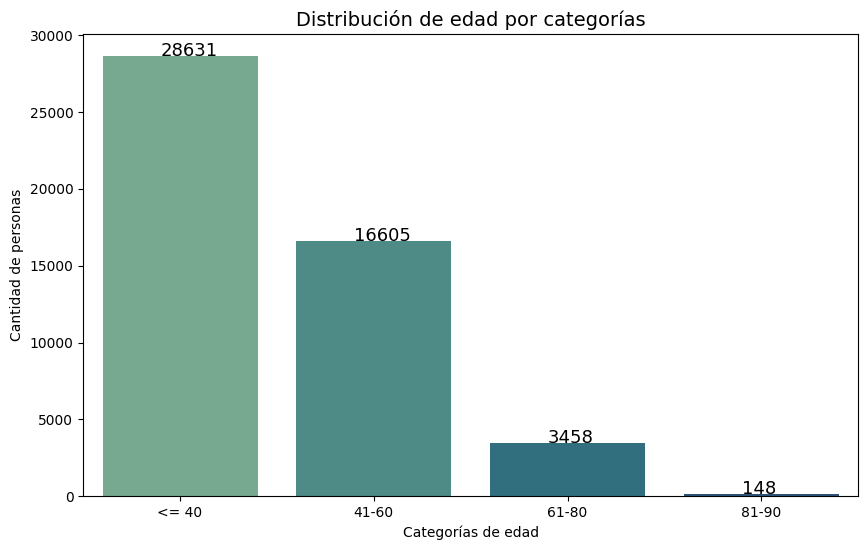

In [2]:

# ── 2. Exploración del dataset ────────────────────────────────────────────────
print("Tipos de datos:")
print(DATA.dtypes.to_string())

print("\nValores únicos por columna (variables categóricas):")
for col in DATA.select_dtypes(include='object').columns:
    print(f"  {col:20s}: {DATA[col].nunique()} categorías → {list(DATA[col].unique()[:5])}")

print("\nValores nulos por columna:")
print(DATA.isnull().sum().to_string())

print("\nEstadísticas descriptivas de variables numéricas:")
print(DATA.describe().round(1).to_string())

# ── Recategorización de age en rangos (necesaria para privacidad diferencial) ─
cp_categorias = ['<= 40', '41-60', '61-80', '81-90']
cut_bins      = [-1, 40, 60, 80, 90]

individuos = DATA.copy()
individuos['age_2'] = pd.cut(individuos['age'], bins=cut_bins, labels=cp_categorias)

print(f"\nDistribución de age por rangos:")
print(individuos['age_2'].value_counts().sort_index().to_string())

# gráfico de distribución de edad recategorizada
plt.figure(figsize=(10, 6))
m = sns.countplot(x='age_2', data=individuos, palette='crest')
for p in m.patches:
    m.annotate('{:.0f}'.format(p.get_height()), (p.get_x() + 0.3, p.get_height()), fontsize=13)
plt.title('Distribución de edad por categorías', fontsize=14)
plt.xlabel('Categorías de edad')
plt.ylabel('Cantidad de personas')
plt.show()


## 2.- Evalúe riesgo de identificación a partir de combinar ‘race', 'gender','age’ 


### Riesgo de reidentificación indirecta

Aunque ninguna variable por sí sola identifique a una persona, la **combinación de varias** puede hacerlo.  
Este fenómeno se llama **reidentificación indirecta** o *linkage attack*.

Aquí combinamos `race`, `gender` y `age` para detectar cuántas personas son únicas en esa combinación — es decir, cuántas personas comparten exactamente los mismos valores en esas tres variables.

- Si una combinación tiene **solo 1 persona**, esa persona es **identificable** aunque el dataset esté "anonimizado".
- El bar plot muestra cuántas combinaciones tienen 1 caso, 2 casos, etc.
- **Las barras con valor 1 representan el riesgo real de reidentificación.**


Primeras filas del conteo por combinación:
                 race  gender  age  n_casos
0  Amer-Indian-Eskimo  Female   17        4
1  Amer-Indian-Eskimo  Female   18        4
2  Amer-Indian-Eskimo  Female   19        7
3  Amer-Indian-Eskimo  Female   20        5
4  Amer-Indian-Eskimo  Female   21        4
5  Amer-Indian-Eskimo  Female   22        7
6  Amer-Indian-Eskimo  Female   23        4
7  Amer-Indian-Eskimo  Female   24        6
8  Amer-Indian-Eskimo  Female   25        4
9  Amer-Indian-Eskimo  Female   26        2

Total de combinaciones únicas (race × gender × age): 575


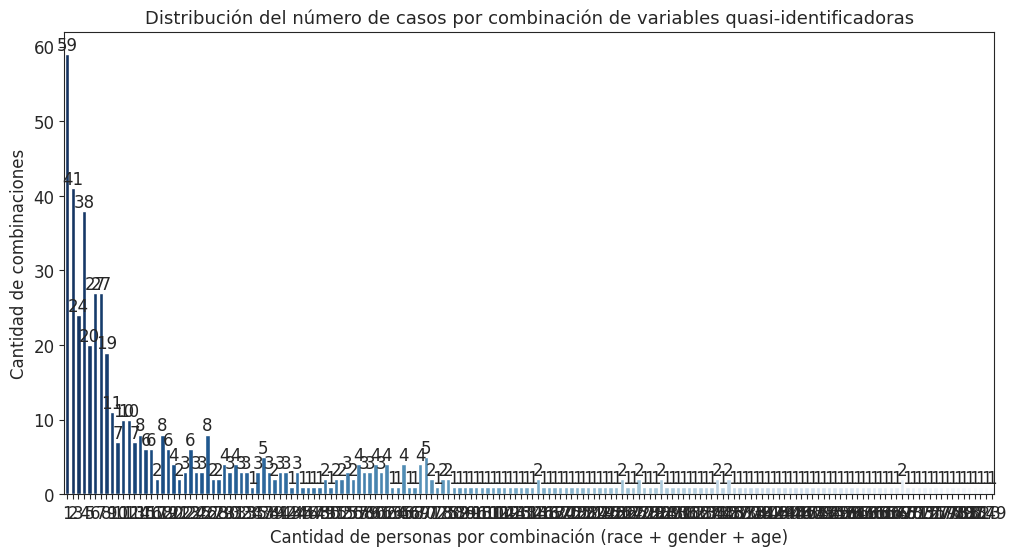


  Evaluación de riesgo de reidentificación
  Total de combinaciones (race × gender × age) : 575
  Combinaciones con 1 solo caso (únicas)       : 59
  Porcentaje sobre el total                    : 10.3%

Conclusión:
  59 combinaciones únicas de race + gender + age tienen
  exactamente 1 persona. Aunque el dataset esté "anonimizado",
  cualquiera que conozca la raza, el género y la edad de una
  persona puede identificarla directamente en el dataset.
  
  Esto confirma la necesidad de aplicar técnicas como la
  Privacidad Diferencial para proteger estos datos.



In [3]:

# ── 3. Evaluación de riesgo de reidentificación ───────────────────────────────

# contamos cuántos individuos comparten cada combinación de race + gender + age
data_riesgo = DATA.groupby(['race', 'gender', 'age'], as_index=False)['workclass'].count()
data_riesgo.rename(columns={'workclass': 'n_casos'}, inplace=True)

print("Primeras filas del conteo por combinación:")
print(data_riesgo.head(10).to_string())
print(f"\nTotal de combinaciones únicas (race × gender × age): {len(data_riesgo)}")

# ── Visualización: cuántas combinaciones tienen 1, 2, 3... casos ─────────────
sns.set_style("ticks")
plt.figure(figsize=(12, 6))

a = sns.countplot(x='n_casos', data=data_riesgo, palette='Blues_r')
a.tick_params(labelsize=12)

for p in a.patches:
    a.annotate('{:.0f}'.format(p.get_height()),
               (p.get_x() + p.get_width() / 2, p.get_height() + 0.5),
               ha='center', fontsize=12)

plt.xlabel("Cantidad de personas por combinación (race + gender + age)", fontsize=12)
plt.ylabel("Cantidad de combinaciones", fontsize=12)
plt.title("Distribución del número de casos por combinación de variables quasi-identificadoras", fontsize=13)
plt.show()

# ── Cálculo del riesgo ────────────────────────────────────────────────────────
casos_unicos    = data_riesgo[data_riesgo['n_casos'] == 1].shape[0]
total_comb      = len(data_riesgo)
porc_unicos     = casos_unicos / total_comb * 100
personas_en_riesgo = data_riesgo[data_riesgo['n_casos'] == 1].shape[0]

print("\n" + "=" * 58)
print("  Evaluación de riesgo de reidentificación")
print("=" * 58)
print(f"  Total de combinaciones (race × gender × age) : {total_comb}")
print(f"  Combinaciones con 1 solo caso (únicas)       : {casos_unicos}")
print(f"  Porcentaje sobre el total                    : {porc_unicos:.1f}%")
print("=" * 58)
print(f"""
Conclusión:
  {casos_unicos} combinaciones únicas de race + gender + age tienen
  exactamente 1 persona. Aunque el dataset esté "anonimizado",
  cualquiera que conozca la raza, el género y la edad de una
  persona puede identificarla directamente en el dataset.
  
  Esto confirma la necesidad de aplicar técnicas como la
  Privacidad Diferencial para proteger estos datos.
""")


- 4.- Aplique Privacidad Diferencial a la variable age


### ¿Por qué `age` y no otra variable?

El **Mecanismo de Laplace** agrega ruido numérico, por lo que se aplica sobre variables **numéricas continuas**.  
`age` cumple esta condición: tiene muchos valores distintos (lo que la hace sensible para reidentificación) y el ruido numérico tiene sentido sobre una edad — sumar o restar ±1 o ±2 años no distorsiona significativamente el análisis agregado.

### Estrategia de privacidad diferencial

Se aplican **dos enfoques complementarios**:

1. **Sobre conteos agregados** (histograma con OpenDP): se agrupa `age` en intervalos, se cuentan las personas por categoría y se agrega ruido de Laplace a esos conteos. Esto protege las estadísticas publicadas.

2. **Sobre valores individuales** (mecanismo de Laplace directo): se agrega ruido directamente a cada valor de `age`. Esto se usa cuando se necesita publicar datos a nivel individual.

El parámetro **ε (epsilon)** controla el balance:
- **ε pequeño** → más ruido → más privacidad → menor precisión
- **ε grande** → menos ruido → menos privacidad → mayor precisión


In [4]:

# ── 4a. Instalación de OpenDP ─────────────────────────────────────────────────
import subprocess, sys
try:
    import opendp
except ImportError:
    print("Instalando opendp...")
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'opendp', '-q'], check=True)
    import opendp

import opendp.prelude as dp
dp.enable_features("contrib", "floating-point")
print(f"OpenDP instalado correctamente")


OpenDP instalado correctamente


  Comparación conteos: real vs con ruido de Laplace
  Epsilon (ε)    : 0.8
  Error total    : 0.3%

           Conteo real  Conteo con ruido
categoria                               
<= 40              560               560
41-60              358               357
61-80               77                76
81-90                5                 6


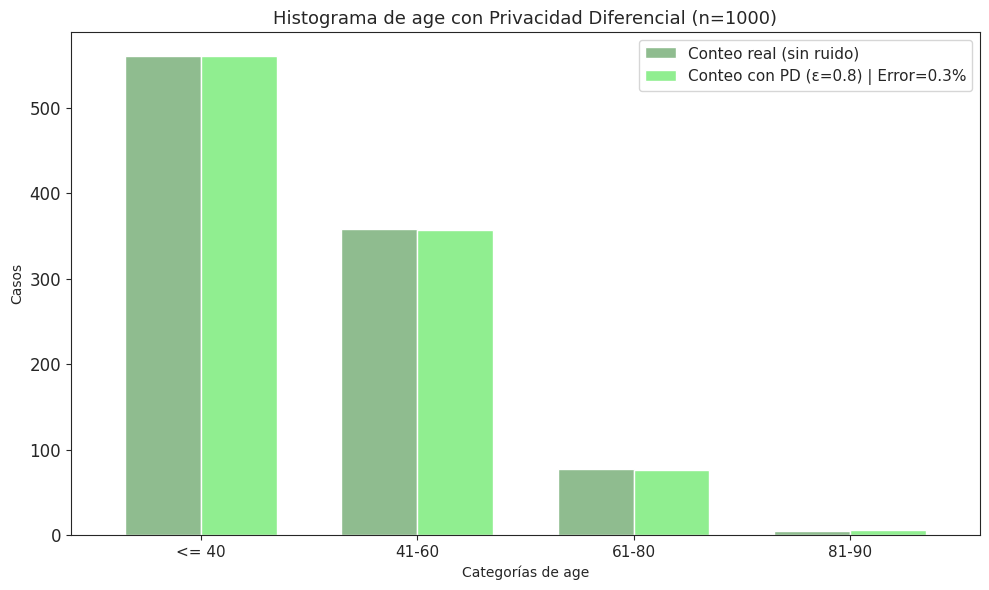


Interpretación:
  Los conteos con ruido son similares a los reales, con pequeñas
  diferencias provocadas por el ruido de Laplace. Ese ruido
  protege la privacidad de las personas sin distorsionar las
  tendencias generales del dataset.



In [5]:

# ── 4b. Privacidad Diferencial sobre conteos — histograma con OpenDP ──────────
#
# Enfoque 1: agregar ruido al CONTEO de personas por rango de edad.
# Se publica cuántas personas hay en cada categoría, con ruido controlado.

categories = ['<= 40', '41-60', '61-80', '81-90']
col_names  = list(individuos.columns)   # usa el df construido en el punto 2

# generamos una muestra de 1000 registros y la guardamos como CSV
# OpenDP trabaja con archivos CSV, no con DataFrames
sample_size = 1000
sample = individuos.sample(n=sample_size, random_state=np.random.seed(2024))
sample.to_csv("samplefile_act18.csv", index=False, header=False)

max_influence = 1       # cada persona aparece en 1 sola categoría
epsilon       = 0.8     # presupuesto de privacidad inicial
budget        = (epsilon, 1e-8)

with open("samplefile_act18.csv") as f:
    data_csv = f.read()

# pipeline SIN ruido: lee CSV → selecciona age_2 → cuenta por categoría
histogram = (
    dp.t.make_split_dataframe(separator=",", col_names=col_names) >>
    dp.t.make_select_column(key="age_2", TOA=str) >>
    dp.t.then_count_by_categories(categories=categories)
)

# pipeline CON ruido: busca la escala de Laplace que cumple ε=0.8
noisy_histogram = dp.binary_search_chain(
    lambda s: histogram >> dp.m.then_laplace(scale=s),
    d_in=max_influence,
    d_out=budget[0]
)

sensitive_counts = histogram(data_csv)          # conteos reales (sin ruido)
np.random.seed(2024)
released_counts  = noisy_histogram(data_csv)    # conteos con ruido de Laplace

# armamos el DataFrame de comparación
sens_rele = pd.DataFrame({
    'Conteo real'        : sensitive_counts,
    'Conteo con ruido'   : released_counts
})
sens_rele = sens_rele[:-1]   # OpenDP agrega una fila extra al final → la eliminamos

# error porcentual
error = sum(abs(sens_rele['Conteo real'] - sens_rele['Conteo con ruido'])) \
        / sum(sens_rele['Conteo real']) * 100

print("=" * 55)
print("  Comparación conteos: real vs con ruido de Laplace")
print("=" * 55)
print(f"  Epsilon (ε)    : {epsilon}")
print(f"  Error total    : {error:.1f}%")
print()
print(sens_rele.assign(categoria=categories).set_index('categoria').to_string())
print("=" * 55)

# gráfico comparativo
labels = ['Conteo real (sin ruido)',
          f'Conteo con PD (ε={epsilon}) | Error={error:.1f}%']
colors = ['darkseagreen', 'lightgreen']

sens_rele.plot.bar(figsize=(10, 6), width=0.7, fontsize=12, color=colors)
plt.legend(fontsize=11, labels=labels)
plt.title(f'Histograma de age con Privacidad Diferencial (n={sens_rele["Conteo real"].sum()})',
          fontsize=13)
plt.xticks(range(len(categories)), categories, rotation=0, fontsize=11)
plt.xlabel('Categorías de age')
plt.ylabel('Casos')
plt.tight_layout()
plt.show()

print("""
Interpretación:
  Los conteos con ruido son similares a los reales, con pequeñas
  diferencias provocadas por el ruido de Laplace. Ese ruido
  protege la privacidad de las personas sin distorsionar las
  tendencias generales del dataset.
""")


In [ ]:

# ── 4c. Evaluación para distintos epsilons y tamaños de muestra ───────────────
#
# Repetimos el análisis con distintos valores de ε para ver el trade-off
# entre privacidad (ε pequeño → más ruido) y precisión (ε grande → menos ruido)

def evaluacion_pd(datos, sample_sizes, epsilons, categories, col_names, name_key):
    """Evalúa el error de privacidad diferencial para distintos ε y tamaños de muestra."""
    for sample_size in sample_sizes:
        sample = datos.sample(n=sample_size, random_state=np.random.seed(2024))
        sample.to_csv('samplefile_act18.csv', index=False, header=False)

        with open('samplefile_act18.csv') as f:
            data = f.read()

        dp.enable_features("contrib", "floating-point")
        max_influence = 1

        histogram = (
            dp.t.make_split_dataframe(separator=",", col_names=col_names) >>
            dp.t.make_select_column(key=name_key, TOA=str) >>
            dp.t.then_count_by_categories(categories=categories)
        )
        sensitive_counts = histogram(data)
        df_comp = pd.DataFrame({'Conteo real': sensitive_counts})
        labels  = ['Conteo real (sin ruido)']

        for eps in epsilons:
            noisy_hist = dp.binary_search_chain(
                lambda s: histogram >> dp.m.then_laplace(scale=s),
                d_in=max_influence, d_out=eps
            )
            np.random.seed(2024)
            released = noisy_hist(data)
            df_comp[f'ε={eps}'] = released

            error_eps = sum(abs(df_comp['Conteo real'] - df_comp[f'ε={eps}'])) \
                        / sum(df_comp['Conteo real']) * 100
            labels.append(f'ε={eps} | Error={error_eps:.1f}%')

        df_comp = df_comp[:-1]
        colors  = ['darkseagreen', 'lightgreen', 'mediumseagreen', 'limegreen', 'green']
        df_comp.plot.bar(figsize=(11, 6), width=0.8, fontsize=11, color=colors)
        plt.legend(fontsize=10, labels=labels)
        plt.title(f'Distribución de age — n={df_comp["Conteo real"].sum()} | múltiples ε', fontsize=13)
        plt.xticks(range(len(categories)), categories, rotation=0, fontsize=11)
        plt.xlabel('Categorías de age')
        plt.ylabel('Casos')
        plt.tight_layout()
        plt.show()

evaluacion_pd(
    individuos,
    sample_sizes = [10000, 30000, 48842],       # tamaños de muestra a evaluar
    epsilons     = [0.8, 0.5, 0.25, 0.05],      # valores de epsilon
    categories   = ['<= 40', '41-60', '61-80', '81-90'],
    col_names    = list(individuos.columns),
    name_key     = 'age_2'
)



### Aplicación de ruido a valores individuales de `age`

Además del histograma con conteos, también se puede agregar ruido directamente a cada valor de `age`.  
Esto se usa cuando se necesita publicar datos a nivel de individuo (no solo estadísticas agregadas).

El ruido sigue una distribución de Laplace centrada en 0, con escala = sensibilidad / ε:
$$\text{age\_privada} = \text{age} + \text{Laplace}\left(0,\ \frac{\Delta f}{\varepsilon}\right)$$

donde $\Delta f = 1$ (sensibilidad: cambiar un individuo altera el valor en 1 como máximo).


Comparación estadísticas: age original vs age con ruido
--------------------------------------------------
            age  age_con_ruido
count  48842.00       48842.00
mean      38.64          39.42
std       13.71          13.71
min       17.00          17.77
25%       28.00          28.77
50%       37.00          37.77
75%       48.00          48.77
max       90.00          90.77


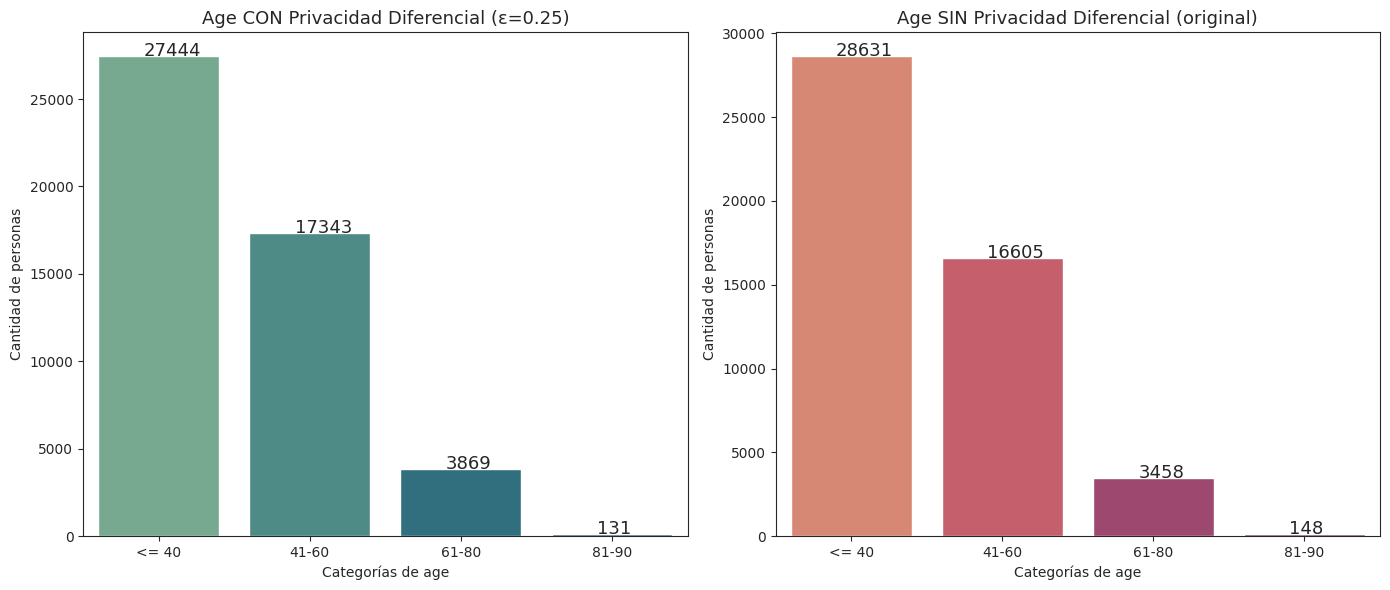


Conclusión final:
  - Ambas distribuciones (con y sin ruido) son prácticamente
    idénticas a nivel agregado por categorías de edad.
  - Esto confirma que la Privacidad Diferencial con el Mecanismo
    de Laplace protege la identidad individual sin distorsionar
    la utilidad analítica del dataset.
  - Dado el riesgo de reidentificación detectado en el punto 3
    (combinaciones únicas de race + gender + age), aplicar PD
    sobre age es una medida eficaz para reducir ese riesgo.



In [6]:

# ── 4d. Ruido directo sobre cada valor individual de age ──────────────────────

def aplicar_ruido_laplace(data, variable, variable_new, sensitivity, epsilon):
    """
    Agrega ruido de Laplace a cada valor individual de una variable numérica.
    
    Parámetros:
        data         → DataFrame
        variable     → columna original
        variable_new → nombre de la columna con ruido
        sensitivity  → sensibilidad de la consulta (Δf = 1 para age)
        epsilon      → presupuesto de privacidad
    """
    np.random.seed(2024)
    data[variable_new] = data[variable] + np.random.laplace(loc=0, scale=sensitivity / epsilon)
    return data

# aplicamos con ε=0.25 (buen balance entre privacidad y utilidad)
epsilon_elegido = 0.25
dapar = aplicar_ruido_laplace(individuos.copy(), 'age', 'age_con_ruido', 1, epsilon_elegido)

print("Comparación estadísticas: age original vs age con ruido")
print("-" * 50)
comp = dapar[['age', 'age_con_ruido']].describe().round(2)
print(comp.to_string())

# ── Comparación visual: distribución con ruido vs sin ruido ──────────────────
edad_cat   = ['<= 40', '41-60', '61-80', '81-90']
bins_edad  = [-1, 40, 60, 80, 90]

dapar['age_ruido_cat']    = pd.cut(dapar['age_con_ruido'], bins=bins_edad, labels=edad_cat)
dapar['age_original_cat'] = pd.cut(dapar['age'],           bins=bins_edad, labels=edad_cat)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# gráfico CON ruido
dp3 = sns.countplot(x='age_ruido_cat', data=dapar, palette='crest', ax=axes[0])
for p in dp3.patches:
    dp3.annotate('{:.0f}'.format(p.get_height()),
                 (p.get_x() + 0.3, p.get_height()), fontsize=13)
axes[0].set_title(f'Age CON Privacidad Diferencial (ε={epsilon_elegido})', fontsize=13)
axes[0].set_xlabel('Categorías de age')
axes[0].set_ylabel('Cantidad de personas')

# gráfico SIN ruido
dp4 = sns.countplot(x='age_original_cat', data=dapar, palette='flare', ax=axes[1])
for p in dp4.patches:
    dp4.annotate('{:.0f}'.format(p.get_height()),
                 (p.get_x() + 0.3, p.get_height()), fontsize=13)
axes[1].set_title('Age SIN Privacidad Diferencial (original)', fontsize=13)
axes[1].set_xlabel('Categorías de age')
axes[1].set_ylabel('Cantidad de personas')

plt.tight_layout()
plt.show()

print("""
Conclusión final:
  - Ambas distribuciones (con y sin ruido) son prácticamente
    idénticas a nivel agregado por categorías de edad.
  - Esto confirma que la Privacidad Diferencial con el Mecanismo
    de Laplace protege la identidad individual sin distorsionar
    la utilidad analítica del dataset.
  - Dado el riesgo de reidentificación detectado en el punto 3
    (combinaciones únicas de race + gender + age), aplicar PD
    sobre age es una medida eficaz para reducir ese riesgo.
""")
